In [ ]:
import numpy as np
from tools.core import *

import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.colors import LogNorm
import mpltern
from mpltern.datasets import get_triangular_grid

sns.set_palette('colorblind')
sns.set_context("paper", rc={"font.size": 6, "axes.titlesize": 7, "axes.labelsize": 7, "xtick.labelsize":6, "ytick.labelsize":6, 'legend.fontsize':6, "legend.title_fontsize":7})
plt.rcParams['svg.fonttype'] = 'none'
cm = 1/2.54  # centimeters in inches

In [2]:
p_x, p_y, p_z = get_triangular_grid(40)

dict_Z = {
    'I' : np.eye(3),
    'Z' : np.array([
            [1., 0.5, 0],
            [0.5, 1., 0],
            [0, 0, 1.]
        ])
}

for p in np.array([p_x, p_y, p_z]).T:
    if 0 in p:
        continue
    assert is_CND(get_hessian(dict_Z['Z'], 3, p)), p

In [23]:
values = {
    'I': {1: None, 2: None, 3: None}, 'Z': {1: None, 2: None, 3: None}
}
clines = {
    'I': {1: None, 2: None, 3: None}, 'Z': {1: None, 2: None, 3: None}
}

q = np.array([1., 1., 1.])/3
P = np.array([
    [0.5, .25, 0.25],
    [0.6, .2, .2],
    [.8, .1, .1]
])

for zname, Z in dict_Z.items():
    for a in [1,2,3]:
        values[zname][a] = get_divergence(Z, a, np.array([p_x, p_y, p_z]).T, q)
        clines[zname][a] = get_divergence(Z, a, P, q)

In [27]:
levels = {1: np.linspace(0, max(values['I'][1].max(), values['Z'][1].max()), 30), 2: np.linspace(0, max(values['I'][2].max(), values['Z'][2].max()), 30), 3: np.linspace(0, max(values['I'][3].max(), values['Z'][3].max()), 30) }

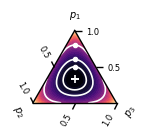

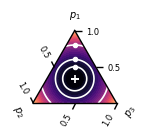

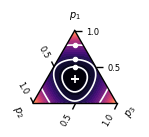

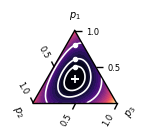

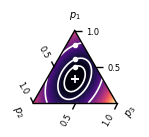

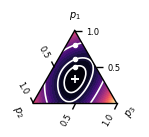

In [ ]:
for zname in dict_Z.keys():
    for a in [1,2,3]:
        fig = plt.figure(figsize=(3.5*cm, 3.5*cm), layout='constrained')
        ax = fig.add_subplot(1,1,1, projection="ternary")
        cs = ax.tricontourf(p_x, p_y, p_z, values[zname][a], levels=levels[a], cmap='magma')
        ax.tricontour(p_x, p_y, p_z, values[zname][a], levels=clines[zname][a], colors='white')
        ax.scatter(*q, marker='+', s=30, c='white')
        for p in P:
            ax.scatter(*p, marker='o', s=10, c='white')
        ax.set_tlabel(r'$p_1$')
        ax.set_llabel(r'$p_2$')
        ax.set_rlabel(r'$p_3$')
        ax.taxis.set_ticks([.5, 1.])
        ax.laxis.set_ticks([.5, 1.])
        ax.raxis.set_ticks([.5, 1.])

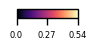

In [ ]:
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(2*cm, .3*cm),)
norm = mpl.colors.Normalize(vmin=0, vmax=levels[3][-1])
cbar = mpl.colorbar.ColorbarBase(
    ax,
    cmap='magma',
    norm=norm,
    orientation="horizontal",
)
ax.set_xticks(np.linspace(0, levels[3][-1], 3), np.round(np.linspace(0, levels[3][-1], 3), 2))

In [29]:
import matplotlib.tri as mtri
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

In [37]:
p_x, p_y, p_z = get_triangular_grid(80)
Z = dict_Z['Z']

q = np.array([1., 1., 1.])/3
P = np.array([
    [0.6, .2, .2]
])

values1 = get_divergence(Z, 1., np.array([p_x, p_y, p_z]).T, q)
level1 = get_divergence(Z, 1., P, q)

values3 = get_divergence(Z, 3., np.array([p_x, p_y, p_z]).T, q)
level3 = get_divergence(Z, 3., P, q)

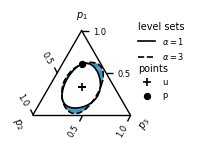

In [55]:
fig = plt.figure(figsize=(5*cm, 3.5*cm), layout='constrained')
ax = fig.add_subplot(1,1,1, projection="ternary")

ax.tricontour(p_x, p_y, p_z, values1, levels=level1, colors='black', linestyles='-')
ax.tricontour(p_x, p_y, p_z, values3, levels=level3, colors='black', linestyles='--')

tri = mtri.Triangulation(p_x, p_y)
tris = tri.triangles

# Triangle centroids in ternary coordinates
cx = p_x[tris].mean(axis=1)
cy = p_y[tris].mean(axis=1)
cz = p_z[tris].mean(axis=1)
centers = np.column_stack([cx, cy, cz])

# Evaluate the same condition at triangle centers
c1 = get_divergence(Z, 1., centers, q)
c3 = get_divergence(Z, 3., centers, q)

# Keep only triangles between the two conditions
keep = (c3 < level3) & (c1 > level1)

# Shade those triangles
ax.tripcolor(
    p_x, p_y, p_z,
    np.ones_like(p_x),
    triangles=tris[keep],
    shading="flat",
    cmap=ListedColormap([sns.color_palette('colorblind')[0]]),
    alpha=0.2,
)


ax.set_tlabel(r'$p_1$')
ax.set_llabel(r'$p_2$')
ax.set_rlabel(r'$p_3$')
ax.taxis.set_ticks([.5, 1.])
ax.laxis.set_ticks([.5, 1.])
ax.raxis.set_ticks([.5, 1.])

ax.scatter(*q, marker='+', s=30, color='black', label='u')
ax.scatter(*P[0], marker='o', s=20, color='black', alpha=1., label='p')

legend_lines = [
    Line2D([0], [0], color='black', ls='-', label=r'$\alpha=1$'),
    Line2D([0], [0], color='black', ls='--', label=r'$\alpha=3$'),
]

ax.add_artist(
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.0, 0.7),  
        title="points",
        frameon=False
    )    
)

ax.legend(
        handles=legend_lines,
        loc="upper left",
        bbox_to_anchor=(1.0, 1.2),
        title = 'level sets',
        frameon=False
    )